In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from src.models.mlp import train_mlp
from src.models.metrics import evaluate_model
from src.visualization.plots import (
    plot_roc_curve,
    plot_mlp_loss_curve,
    plot_mlp_validation_curve,
    plot_threshold_metrics, plot_confusion_matrix,
)
from src.models.threshold import (
    find_best_threshold
)

In [2]:
df = pd.read_parquet("../data/processed/traffic_crashes_hourly.parquet")

FEATURES_NUMERIC = [
    "avg_speed",
    "avg_free_flow_speed",
    "avg_congestion",
    "segment_lat",
    "segment_lon",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

FEATURES_CATEGORICAL = [
    "segment_id"
]

FEATURES = FEATURES_NUMERIC + FEATURES_CATEGORICAL

TARGET = "accident"

y = df[TARGET]

ros = RandomOverSampler(
    random_state=42
)

TRAIN MLP ON NUMERIC FEATURES

Iteration 1, loss = 0.62422801
Validation score: 0.656733
Iteration 2, loss = 0.61171273
Validation score: 0.667062
Iteration 3, loss = 0.60572611
Validation score: 0.670790
Iteration 4, loss = 0.60249302
Validation score: 0.671679
Iteration 5, loss = 0.60014350
Validation score: 0.673501
Iteration 6, loss = 0.59834673
Validation score: 0.674820
Iteration 7, loss = 0.59670346
Validation score: 0.674226
Iteration 8, loss = 0.59533994
Validation score: 0.675046
Iteration 9, loss = 0.59433581
Validation score: 0.675949
Iteration 10, loss = 0.59353117
Validation score: 0.676548
Iteration 11, loss = 0.59281086
Validation score: 0.676687
Iteration 12, loss = 0.59199543
Validation score: 0.676934
Iteration 13, loss = 0.59142858
Validation score: 0.678063
Iteration 14, loss = 0.59088230
Validation score: 0.678966
Iteration 15, loss = 0.59038514
Validation score: 0.679391
Iteration 16, loss = 0.58984280
Validation score: 0.679433
Iteration 17, loss = 0.58946014
Validation score: 0.679334
Iterat

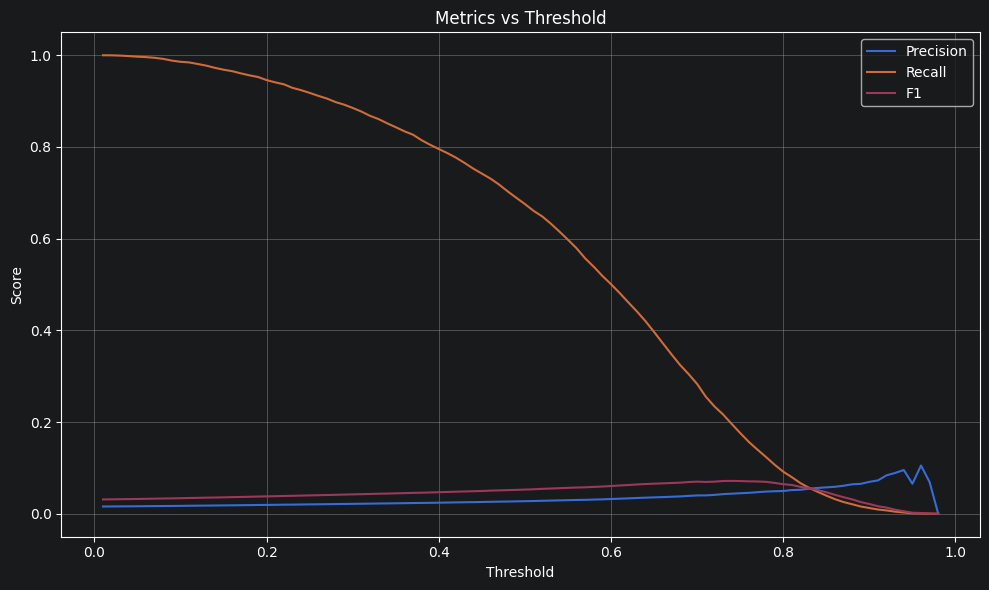


 MLP Numeric Classification Report
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    415082
           1       0.04      0.20      0.07      6666

    accuracy                           0.92    421748
   macro avg       0.52      0.56      0.51    421748
weighted avg       0.97      0.92      0.94    421748


 MLP Numeric Metrics
ROC-AUC: 0.7010
PR_AUC: 0.0345
Accuracy: 0.9197
Precision: 0.0439
Recall: 0.1962
F1: 0.0717


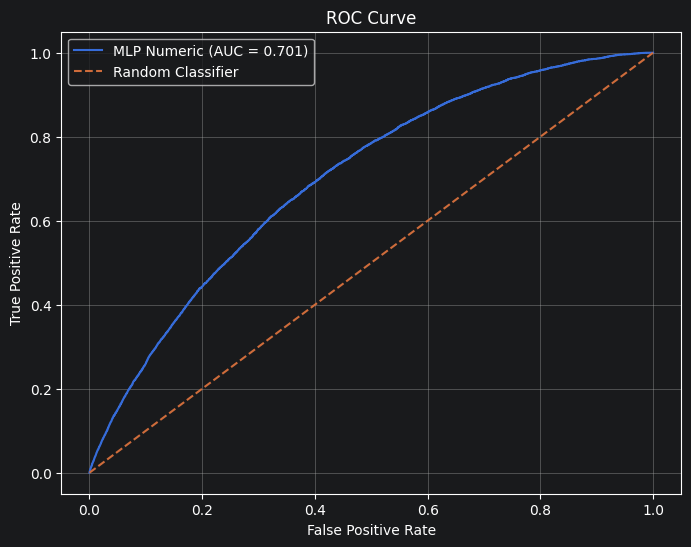

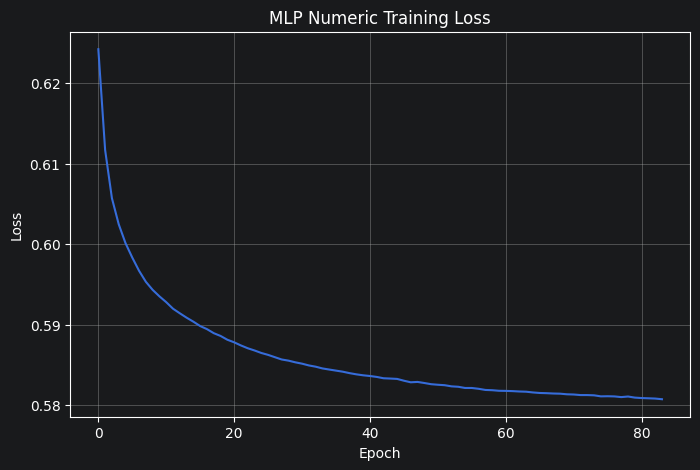

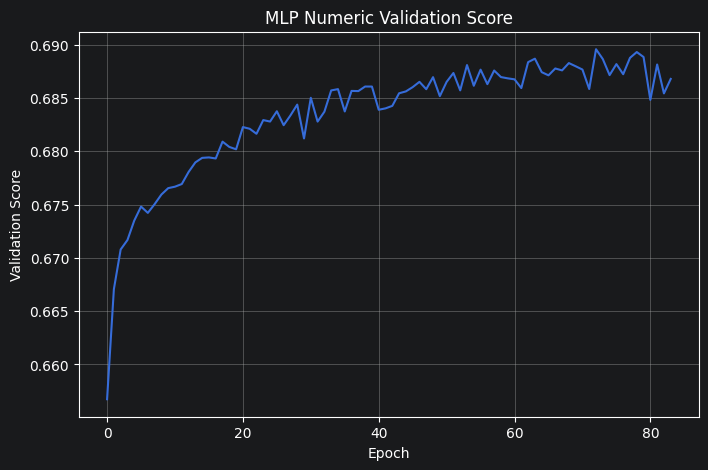

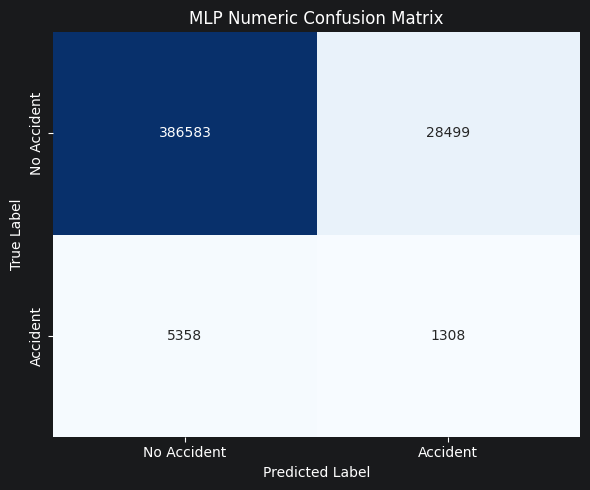

In [3]:
X = df[FEATURES_NUMERIC]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

mlp_1 = train_mlp(
    X_train_balanced,
    y_train_balanced,
    X_test,
    FEATURES_NUMERIC
)

y_proba_mlp_1, y_pred_mlp_1, pipeline_mlp_1 = mlp_1

best_threshold_mlp_1, threshold_results_mlp_1 = (
    find_best_threshold(
        y_test,
        y_proba_mlp_1
    )
)

print(
    f"Best threshold: {best_threshold_mlp_1:.3f}"
)

plot_threshold_metrics(
    threshold_results_mlp_1
)

y_pred_best_mlp_1 = (
    y_proba_mlp_1 >= best_threshold_mlp_1
).astype(int)

metrics_mlp_1 = evaluate_model(
    y_test,
    y_pred_best_mlp_1,
    y_proba_mlp_1,
    "MLP Numeric"
)

plot_roc_curve(
    y_test,
    y_proba_mlp_1,
    "MLP Numeric",
    metrics_mlp_1["ROC-AUC"]
)

plot_mlp_loss_curve(
    pipeline_mlp_1,
    "MLP Numeric Training Loss",
)

plot_mlp_validation_curve(
    pipeline_mlp_1,
    "MLP Numeric Validation Score"
)

plot_confusion_matrix(
    y_test,
    y_pred_best_mlp_1,
    "MLP Numeric"
)

TRAIN MLP ON NUMERIC FEATURES + CATEGORICAL FEATURES (SEGMENT_ID)

Iteration 1, loss = 0.45984684
Validation score: 0.836472
Iteration 2, loss = 0.33680712
Validation score: 0.876657
Iteration 3, loss = 0.29357688
Validation score: 0.890259
Iteration 4, loss = 0.27026710
Validation score: 0.903055
Iteration 5, loss = 0.25468171
Validation score: 0.911611
Iteration 6, loss = 0.24305564
Validation score: 0.913490
Iteration 7, loss = 0.23376813
Validation score: 0.920467
Iteration 8, loss = 0.22649537
Validation score: 0.925015
Iteration 9, loss = 0.22005337
Validation score: 0.927448
Iteration 10, loss = 0.21510057
Validation score: 0.923437
Iteration 11, loss = 0.21082420
Validation score: 0.928752
Iteration 12, loss = 0.20723098
Validation score: 0.931032
Iteration 13, loss = 0.20438137
Validation score: 0.933507
Iteration 14, loss = 0.20163190
Validation score: 0.934712
Iteration 15, loss = 0.19898199
Validation score: 0.935431
Iteration 16, loss = 0.19724189
Validation score: 0.937118
Iteration 17, loss = 0.19553941
Validation score: 0.936690
Iterat

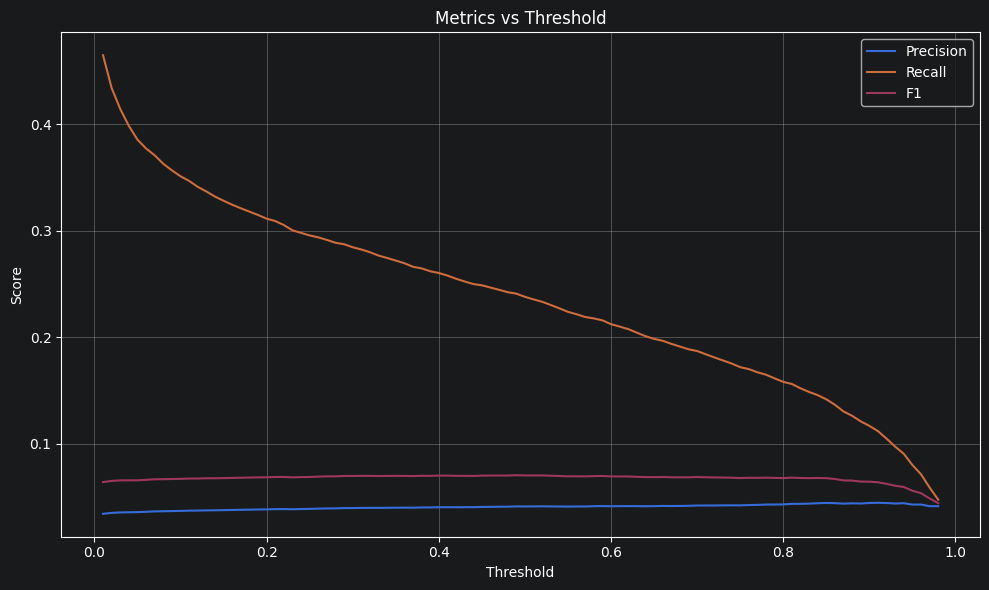


 MLP Numeric + Categorical Classification Report
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    415082
           1       0.04      0.24      0.07      6666

    accuracy                           0.90    421748
   macro avg       0.51      0.58      0.51    421748
weighted avg       0.97      0.90      0.93    421748


 MLP Numeric + Categorical Metrics
ROC-AUC: 0.7096
PR_AUC: 0.0327
Accuracy: 0.8998
Precision: 0.0414
Recall: 0.2411
F1: 0.0707


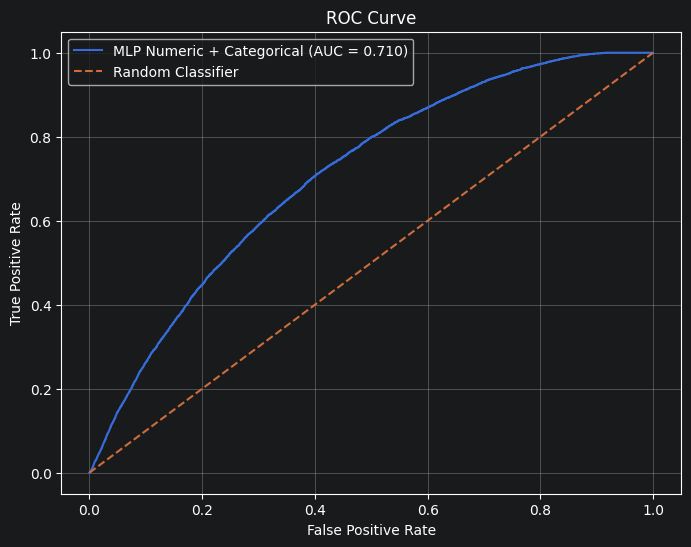

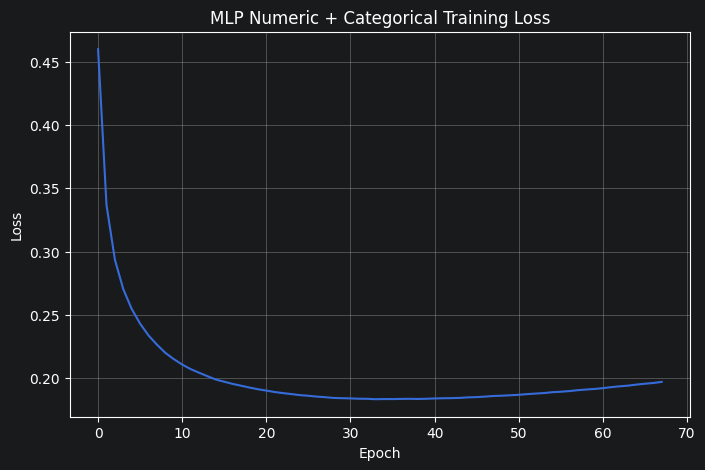

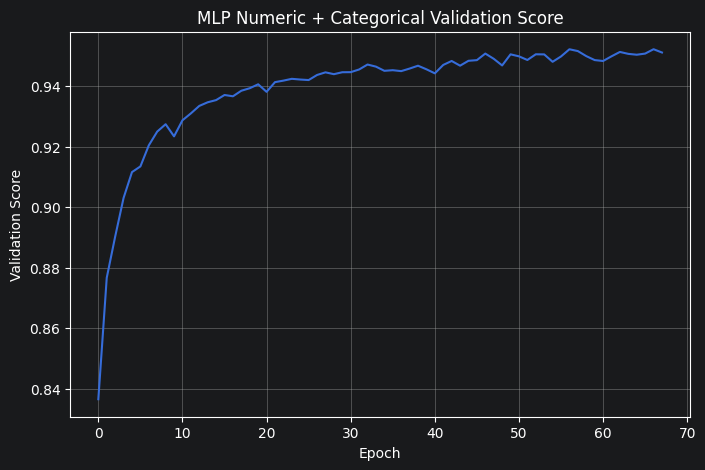

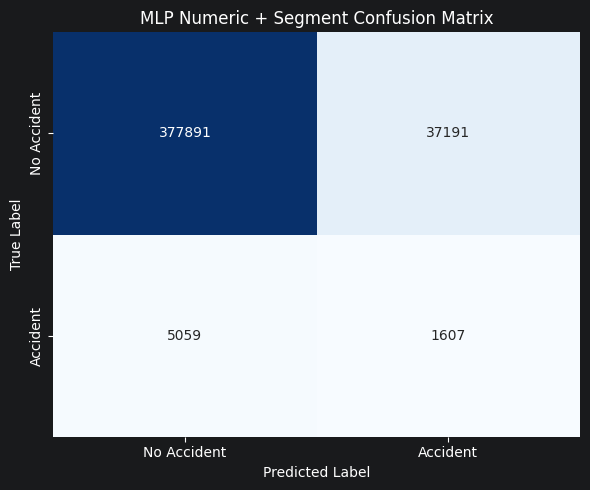

In [4]:
X = df[FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

mlp_2 = train_mlp(
    X_train_balanced,
    y_train_balanced,
    X_test,
    FEATURES_NUMERIC,
    FEATURES_CATEGORICAL,
)

y_proba_mlp_2, y_pred_mlp_2, pipeline_mlp_2 = mlp_2

best_threshold_mlp_2, threshold_results_mlp_2 = (
    find_best_threshold(
        y_test,
        y_proba_mlp_2
    )
)

print(
    f"Best threshold: {best_threshold_mlp_2:.3f}"
)

plot_threshold_metrics(
    threshold_results_mlp_2
)

y_pred_best_mlp_2 = (
    y_proba_mlp_2 >= best_threshold_mlp_2
).astype(int)

metrics_mlp_2 = evaluate_model(
    y_test,
    y_pred_best_mlp_2,
    y_proba_mlp_2,
    "MLP Numeric + Categorical"
)

plot_roc_curve(
    y_test,
    y_proba_mlp_2,
    "MLP Numeric + Categorical",
    metrics_mlp_2["ROC-AUC"]
)

plot_mlp_loss_curve(
    pipeline_mlp_2,
"MLP Numeric + Categorical Training Loss"
)

plot_mlp_validation_curve(
    pipeline_mlp_2,
    "MLP Numeric + Categorical Validation Score",
)

plot_confusion_matrix(
    y_test,
    y_pred_best_mlp_2,
    "MLP Numeric + Segment"
)